# CIFAKE: Detección de Imágenes Generadas por IA
## Versión Simple - 5000 imágenes por clase

## 1. Importar librerías

In [ ]:
 !pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.19.0


In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.


## 2. Cargar datos (5000 de cada clase)

In [ ]:
train_path = Path(path) / 'train'
test_path = Path(path) / 'test'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path, image_size=(32, 32), batch_size=32,
    class_names=['FAKE', 'REAL'], label_mode='binary')

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path, image_size=(32, 32), batch_size=32,
    class_names=['FAKE', 'REAL'], label_mode='binary')

print('Datos cargados')

Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Datos cargados


## 3. Preparar datos

In [ ]:
def normalize(images, labels):
    return images / 255.0, labels

train_ds = train_ds.map(normalize).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(normalize).cache().prefetch(tf.data.AUTOTUNE)

print('Datos normalizados')

Datos normalizados


## 4. Ver ejemplos

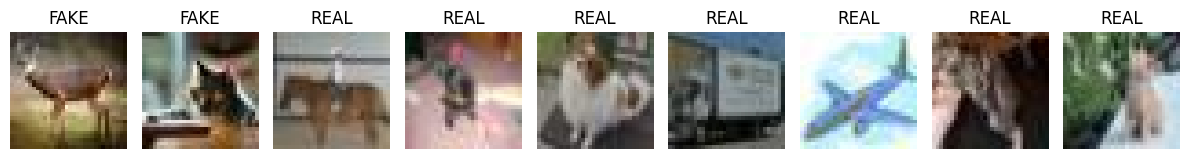

In [ ]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 4))
    for i in range(9):
        plt.subplot(1, 9, i + 1)
        plt.imshow(images[i])
        label = 'REAL' if labels[i] == 1 else 'FAKE'
        plt.title(label)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## 5. Crear modelo CNN

In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation='relu'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(128, 3, activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenar

In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=test_ds)
print('\nEntrenamiento completado')

Epoch 1/10
 198/3125 ━━━━━━━━━━━━━━━━━━━━ 5:32 114ms/step - accuracy: 0.6201 - loss: 0.6406

## 7. Evaluar

In [ ]:
loss, accuracy = model.evaluate(test_ds)
print(f'\nPérdida: {loss:.4f}')
print(f'Exactitud: {accuracy:.4f} ({accuracy*100:.2f}%)')

## 8. Gráficos

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()

## 9. Predicciones

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

y_true, y_pred, y_proba = [], [], []
for images, labels in test_ds:
    pred = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((pred > 0.5).astype(int).flatten())
    y_proba.extend(pred.flatten())

y_true, y_pred, y_proba = np.array(y_true), np.array(y_pred), np.array(y_proba)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.ylabel('Verdadero')
plt.xlabel('Predicción')
plt.show()

print(classification_report(y_true, y_pred, target_names=['FAKE', 'REAL']))

## 10. Curva ROC

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('Tasa Falsos Positivos')
plt.ylabel('Tasa Verdaderos Positivos')
plt.legend()
plt.grid()
plt.show()

## 11. Guardar

In [ ]:
# Función para guardar el modelo

# model.save('modelo_cifake.h5')
# print('Modelo guardado')